# Dự đoán hành khách sống sót trên tàu Spaceship Titanic bằng Ensemble Learning

## 1. Mô tả dữ liệu
- `PassengerId`: Mã định danh duy nhất (định dạng `gggg_pp`).
- `HomePlanet`: Hành tinh quê hương.
- `CryoSleep`: Trạng thái ngủ đông.
- `Cabin`: Số cabin (`Deck/Num/Side`).
- `Destination`: Hành tinh đích.
- `Age`: Tuổi.
- `VIP`: Khách hàng VIP.
- `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`: Số tiền chi tiêu cho các dịch vụ.
- `Name`: Tên hành khách.
- `Transported`: Biến mục tiêu (True/False).
## 2. Khai báo một số thư viện

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [6]:
train_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")
train_df.head()

Kích thước tập Train: (8693, 14)
Kích thước tập Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Khám phá dữ liệu (EDA) và Kỹ nghệ đặc trưng (Feature Engineering)

Để đạt điểm số > 80%, việc xử lý dữ liệu và tạo tính năng mới là quan trọng nhất:
- **Xử lý Cabin**: Tách thành `Cabin_deck`, `Cabin_num`, và `Cabin_side` (Cực kỳ quan trọng vì vị trí tàu quyết định tỉ lệ sống sót).
- **Tổng chi tiêu**: Cộng gộp tất cả các khoảng chi tiêu dịch vụ thành `Total_Spending`. Những người ngủ đông (`CryoSleep` = True) sẽ có chi tiêu bằng 0.
- **Nhóm hành khách**: Trích xuất mã nhóm từ `PassengerId` để xem họ đi một mình hay đi theo đoàn.

In [7]:
def preprocess_data(df):
    df_clean = df.copy()
    
    df_clean['Group'] = df_clean['PassengerId'].apply(lambda x: x.split('_')[0])
    group_sizes = df_clean['Group'].value_counts()
    df_clean['GroupSize'] = df_clean['Group'].map(group_sizes)
    df_clean['IsAlone'] = (df_clean['GroupSize'] == 1).astype(int)
    
    df_clean['Cabin'].fillna('Unknown/Unknown/Unknown', inplace=True)
    df_clean['Cabin_deck'] = df_clean['Cabin'].apply(lambda x: x.split('/')[0])
    df_clean['Cabin_side'] = df_clean['Cabin'].apply(lambda x: x.split('/')[2])
    
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        df_clean[col].fillna(0, inplace=True)
    df_clean['Total_Spending'] = df_clean[spend_cols].sum(axis=1)
    df_clean['No_Spending'] = (df_clean['Total_Spending'] == 0).astype(int)
    
    df_clean['CryoSleep'] = df_clean['CryoSleep'].fillna(df_clean['No_Spending'] == 1)
    df_clean['HomePlanet'].fillna(df_clean['HomePlanet'].mode()[0], inplace=True)
    df_clean['Destination'].fillna(df_clean['Destination'].mode()[0], inplace=True)
    df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
    df_clean['VIP'].fillna(False, inplace=True)
    
    categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side']
    le = LabelEncoder()
    for col in categorical_cols:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        
    drop_cols = ['PassengerId', 'Cabin', 'Name', 'Group']
    df_clean.drop(columns=[col for col in drop_cols if col in df_clean.columns], inplace=True)
    
    return df_clean

X_train_full = preprocess_data(train_df)
y_train = X_train_full.pop('Transported').astype(int)
X_test = preprocess_data(test_df)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print("Hoàn thành tiền xử lý dữ liệu!")

Hoàn thành tiền xử lý dữ liệu!


/tmp/ipykernel_58/4040883640.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Cabin'].fillna('Unknown/Unknown/Unknown', inplace=True)
/tmp/ipykernel_58/4040883640.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## 4. Huấn luyện các mô hình cơ sở (Base Models)

Chúng ta sẽ sử dụng 3 thuật toán Boosting mạnh mẽ nhất hiện nay đối với dữ liệu dạng bảng:
1. **XGBoost**: Thuật toán Gradient Boosting tối ưu hóa cao.
2. **LightGBM**: Tốc độ huấn luyện cực nhanh, hiệu năng cao dựa trên biểu đồ histogram.
3. **CatBoost**: Xử lý cực tốt các biến phân loại và giảm thiểu Overfitting nhờ thuật toán hoán vị.

Chúng ta sẽ đánh giá độ chính xác bằng phương pháp **Stratified 5-Fold Cross-Validation**.


In [8]:
models = {
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(iterations=150, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name}: Accuracy Trung bình = {scores.mean():.4f} (+/- {scores.std():.4f})")

--- BẮT ĐẦU BENCHMARK CÁC MÔ HÌNH ĐƠN LẺ ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: Accuracy Trung bình = 0.8071 (+/- 0.0069)
XGBoost: Accuracy Trung bình = 0.8014 (+/- 0.0087)
CatBoost: Accuracy Trung bình = 0.8002 (+/- 0.0078)


## 5. Kết hợp mô hình bằng Kỹ thuật Ensemble (Stacking Classifier)

**Stacking** là kỹ thuật Ensemble nâng cao:
- **Base-models (Mức 0)**: XGBoost, LightGBM, CatBoost sẽ đưa ra các dự đoán độc lập.
- **Meta-model (Mức 1)**: Sử dụng một mô hình tuyến tính đơn giản như **Logistic Regression** nhận kết quả dự đoán của mức 0 làm đầu vào để đưa ra kết luận cuối cùng. Cách này giúp tận dụng ưu điểm và bù trừ khuyết điểm của từng mô hình đơn lẻ.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Stacking Ensemble: Accuracy Trung bình = 0.8039 (+/- 0.0075)


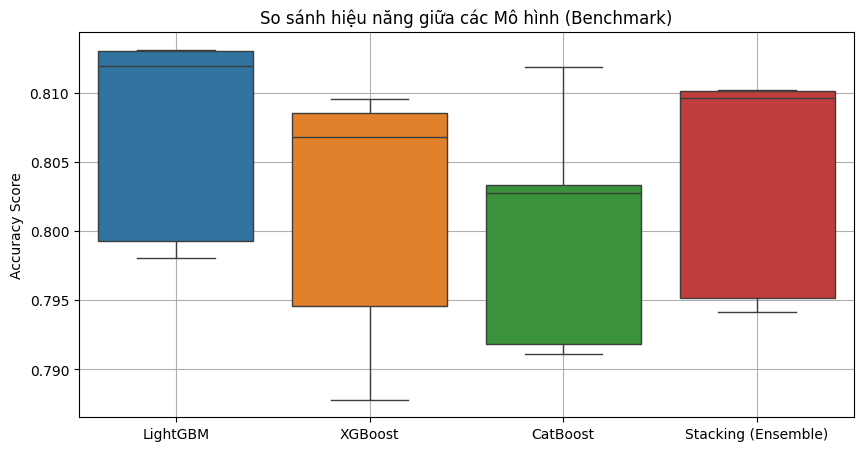

In [10]:
stacking_model = StackingClassifier(
    estimators=[
        ('lgb', models['LightGBM']),
        ('xgb', models['XGBoost']),
        ('cat', models['CatBoost'])
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_scores = cross_val_score(stacking_model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
results['Stacking (Ensemble)'] = stacking_scores

print(f"Stacking Ensemble: Accuracy Trung bình = {stacking_scores.mean():.4f} (+/- {stacking_scores.std():.4f})")

benchmark_df = pd.DataFrame({name: scores for name, scores in results.items()})
plt.figure(figsize=(10, 5))
sns.boxplot(data=benchmark_df)
plt.title('So sánh hiệu năng giữa các Mô hình (Benchmark)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()


In [11]:
stacking_model.fit(X_train_scaled, y_train)

final_predictions = stacking_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_predictions.astype(bool) # Đưa về dạng True/False đúng định dạng gốc
})

submission.to_csv('submission.csv', index=False)
print("File submission.csv đã được tạo thành công!")
print(submission.head())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


File submission.csv đã được tạo thành công!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
